# Inleiding

Voor deze opdracht gaan jullie zelf op zoek naar je eigen dataset. De dataset bevat in ieder geval een kolom met een timestamp (een datum of een tijdstip) met gelijke stapgrootte (uurlijkse/dagelijkse/jaarlijkse data). Daarnaast komt deze tijdaanduiding minstens 36x terug, dus bij het gebruik van maanden minstens 36 maanden. Liever heb je een dataset die groot genoeg is om de train/test splitsing logisch te maken. Denk aan een seizoenseffect dat pas eind van elk jaar gebeurt: dan zou je je testset niet de laatste paar maanden van dat jaar zijn, omdat het zo anders van je trainset zou zijn. 

Let op: In tegenstelling tot de eerste opdracht, voor deze en de resterende 1 opdracht worden jullie peer reviews alleen beoordeeld op een ja of nee basis. 

Zoals geschreven in de vakbeschrijving:

"Het niet op tijd of lui maken van een individuele peer review resulteert in een reductie van 0,5 punt voor het cijfer van de bijhorende opdracht van de reviewer."

Gezien dat jullie peer reviews zijn sowieso kwalitatief beoordeeld voor Opdracht 1, is deze halfpunt reductie alleen voor Opdrachten 2 t/m 4 geldig. 

### Algemene Coderen Conventies

De volgorde van het python script is belangrijk. Zo zorg je bijvoorbeeld altijd dat eerst de benodigde packages worden ingeladen geïnstalleerd en geïmporteerd). Verder is het goed om van tevoren jouw working directory te controleren. 

Schrijf het python script daarom met een duidelijke indeling van met verschillende stappen. Bij elke stap dient toelichting worden gegeven:
1. Wat is het doel van deze stap?
2. Wat is de input van deze stap?
3. Wat is de output van deze stap en waar heb je deze output hierna nog nodig?

Hieronder voorbeelden van de verschillende punten hierboven.

In [1]:
### Stap 0: packages, imports en hulpfuncties
# Doel: alle packages laden en functies klaarzetten die later in de notebook opnieuw worden gebruikt.
# In: standaard Python/Jupyter omgeving.
# Uit: imports, metric-functies en vaste plotinstellingen.

import importlib.util
import subprocess
import sys
import warnings
from pathlib import Path


def ensure_package(import_name, package_name=None):
    """Installeer een package alleen wanneer de import nog niet beschikbaar is."""
    package_name = package_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"{package_name} ontbreekt; installatie wordt gestart...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


# Prophet wordt pas later geimporteerd, omdat dat package wat zwaarder is.
for import_name, package_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("statsmodels", "statsmodels"),
]:
    ensure_package(import_name, package_name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


def _aligned_arrays(y_true, y_pred):
    # Doel: metrics eerlijk berekenen door alleen datums te gebruiken waar beide reeksen waarden hebben.
    # In: werkelijke waarden en voorspelde waarden, als array/Series.
    # Uit: twee numpy arrays met dezelfde lengte zonder missende waarden.
    actual = pd.Series(y_true).astype(float)
    predicted = pd.Series(y_pred).astype(float)
    aligned = pd.concat([actual, predicted], axis=1).dropna()
    return aligned.iloc[:, 0].to_numpy(), aligned.iloc[:, 1].to_numpy()


def rmse(y_true, y_pred):
    actual, predicted = _aligned_arrays(y_true, y_pred)
    return float(np.sqrt(np.mean((actual - predicted) ** 2)))


def mae(y_true, y_pred):
    actual, predicted = _aligned_arrays(y_true, y_pred)
    return float(np.mean(np.abs(actual - predicted)))


print("Working directory:", Path.cwd())


matplotlib ontbreekt; installatie wordt gestart...
  Using cached matplotlib-3.10.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp313-cp313-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 22.3 MB/s  0:00:00
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Working directory: /Users/sekander/Documents/Codex/2026-06-11/files-mentioned-by-the-user-dat

# Theorievragen

Beantwoord voordat je met de dataset aan de slag gaan, eerst de volgende vragen:

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Heeft de theorie vragen beantwoord en de uitleg is begrijpelijk en er worden voorbeelden bij gehaald. De uitleg wordt ondersteund door visualisaties. Ook wordt autocorrelatie, dus beschreven bij de uiteindelijke modellen."

Let op: Deze autocorrelatie is van de residuen na het uitwerken van het model, NIET van de originele data zelf. Deze laatste analyse helpt je bepalen hoe goed je model alle autocorrelatie UIT je data heeft gehaald. 

Wat is autocorrelatie?

Autocorrelatie betekent dat een observatie in een tijdreeks samenhangt met eerdere observaties uit dezelfde reeks. Bij een lag van 1 vergelijk je bijvoorbeeld de waarde van deze maand met de waarde van vorige maand. Als hoge waarden vaak gevolgd worden door hoge waarden, is de autocorrelatie positief. Als hoge waarden juist vaak gevolgd worden door lage waarden, is die negatief.

Voorbeeld: bij CO2-metingen is de concentratie in april meestal sterk gerelateerd aan maart, omdat de atmosfeer niet ineens volledig verandert. Autocorrelatie is belangrijk omdat veel gewone regressiemodellen aannemen dat fouten onafhankelijk zijn. Bij tijdreeksen is dat vaak niet zo. In de ACF-plot zie je autocorrelatie per vertraging (lag). Bij het uiteindelijke model kijk je niet alleen naar autocorrelatie in de originele data, maar vooral naar autocorrelatie in de residuen. Als daar nog veel autocorrelatie in zit, heeft het model nog structuur laten liggen.


Leg het verschil uit tussen een AR model en een MA model.

Een AR-model (AutoRegressive) voorspelt de huidige waarde met eerdere waarden van dezelfde reeks. Een AR(1)-model gebruikt bijvoorbeeld vooral de vorige waarde: als vorige maand hoog was, verwacht het model dat deze maand ook relatief hoog is.

Een MA-model (Moving Average) voorspelt de huidige waarde met eerdere voorspelfouten of schokken. Een MA(1)-model zegt bijvoorbeeld: als het model vorige periode onverwacht te laag zat, dan wordt daar deze periode nog deels voor gecorrigeerd.

Kort gezegd: AR gebruikt het verleden van de tijdreeks zelf, terwijl MA het verleden van de fouttermen gebruikt. In praktijk kunnen beide nuttig zijn: AR vangt traag doorlopende patronen op, MA vangt tijdelijke schokken op die nog even doorwerken.


Hoe werkt een ARIMA model om deze twee methoden te combineren en wat doet het "I" element?

Een ARIMA-model combineert AR en MA in een model: ARIMA(p, d, q). De `p` staat voor het aantal autoregressieve lags, de `q` voor het aantal moving-average lags en de `d` voor het aantal keer dat de reeks wordt gedifferentieerd.

Het `I`-element betekent Integrated. Dat gaat over differencing: je modelleert dan niet direct de originele waarde, maar bijvoorbeeld het verschil tussen deze maand en vorige maand. Dat helpt wanneer een tijdreeks niet stationair is, bijvoorbeeld door een stijgende trend. Door differencing kan de reeks stabieler worden, waardoor AR- en MA-termen beter werken. Voor seizoensdata bestaat ook SARIMA, waarbij naast gewone ARIMA-termen ook seizoens-ARIMA-termen worden toegevoegd, bijvoorbeeld met een periode van 12 maanden.


Geef een korte uitleg over de techniek Exponential Smoothing.

Exponential Smoothing voorspelt toekomstige waarden door eerdere observaties gewogen te middelen, waarbij recente observaties meer gewicht krijgen dan oudere observaties. De gewichten nemen exponentieel af naarmate waarden verder in het verleden liggen.

Er zijn meerdere varianten. Simple Exponential Smoothing gebruikt vooral het niveau van de reeks. Holt's methode voegt een trendcomponent toe. Holt-Winters voegt daar ook seizoenspatronen aan toe. Dit soort modellen is vaak sterk voor korte-termijnvoorspellingen wanneer trend en seizoen redelijk stabiel blijven.


### Visualisatie bij de theorievragen
Onderstaande simulatie laat zien hoe autocorrelatie, AR-gedrag en MA-gedrag er in grote lijnen uitzien. De code is bedoeld als ondersteuning bij de theorie, niet als onderdeel van de uiteindelijke CO2-modellen.


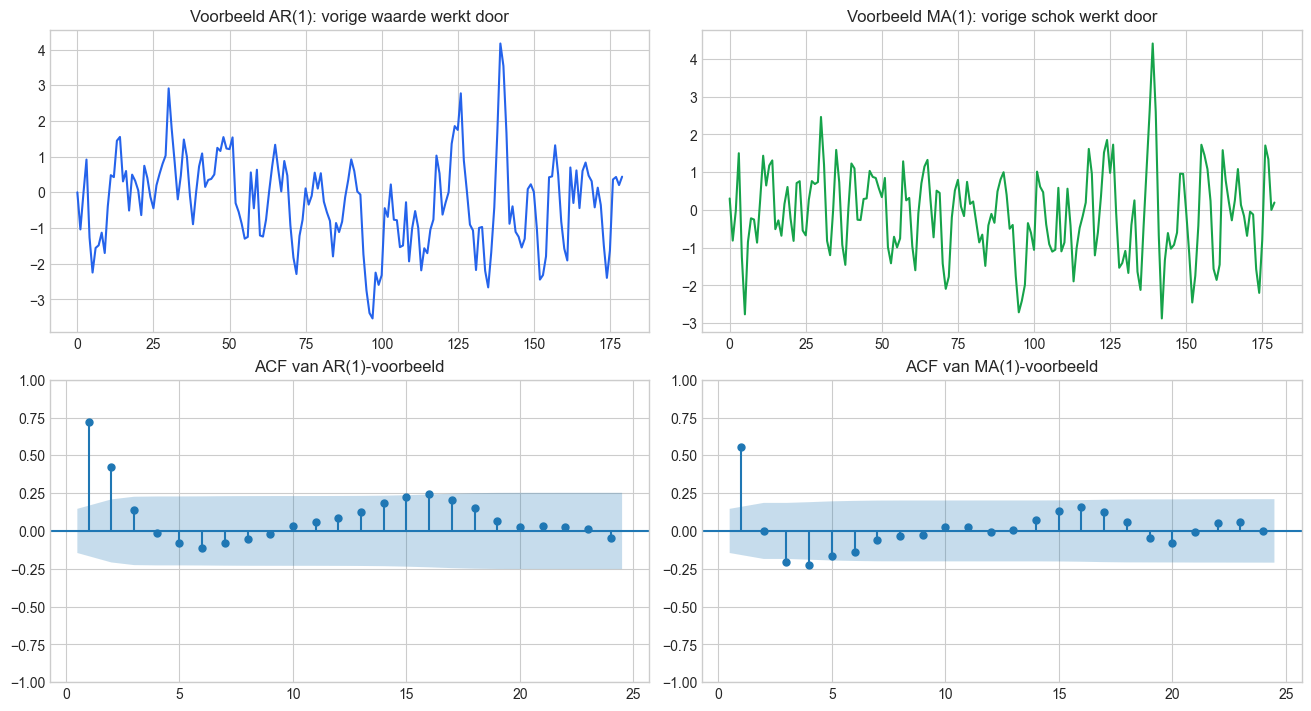

In [2]:
### Theorievisualisatie: AR versus MA en autocorrelatie
# Doel: de theorievragen ondersteunen met een kleine simulatie.
# In: willekeurige fouttermen.
# Uit: voorbeeldreeksen en ACF-plots voor AR(1) en MA(1).

rng = np.random.default_rng(42)
n = 180
errors = rng.normal(0, 1, n)

ar_series = np.zeros(n)
for t in range(1, n):
    ar_series[t] = 0.75 * ar_series[t - 1] + errors[t]

ma_series = errors.copy()
ma_series[1:] = errors[1:] + 0.75 * errors[:-1]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)
axes[0, 0].plot(ar_series, color="#2563eb")
axes[0, 0].set_title("Voorbeeld AR(1): vorige waarde werkt door")
axes[0, 1].plot(ma_series, color="#16a34a")
axes[0, 1].set_title("Voorbeeld MA(1): vorige schok werkt door")
plot_acf(ar_series, lags=24, ax=axes[1, 0], zero=False)
axes[1, 0].set_title("ACF van AR(1)-voorbeeld")
plot_acf(ma_series, lags=24, ax=axes[1, 1], zero=False)
axes[1, 1].set_title("ACF van MA(1)-voorbeeld")
plt.show()


# Deelopdracht 1/3 - Dataverkenning

Splits de data op in een train en test dataset. De traindataset mag niet te klein zijn. Doe de splitsing op chronologische volgorde. Bij bijvoorbeeld januari tot en met december, zouden november en december de testdataset zijn (je kan alleen vooruit in de tijd).

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"Heeft verkennende plots gemaakt. Heeft datatype van tijdsvariabele correct behandeld en gekeken of de tijdreeks geen gaten heeft. Daarnaast is er een goede analyse van trend, seizoenspatronen en autocorrelatie gemaakt. De gevonden patronen worden bediscussieerd en er worden mogelijke verklaringen/interpretaties voor gegeven."

Voor deze opdracht gebruik ik de Mauna Loa CO2-dataset uit `statsmodels`. De dataset bevat atmosferische CO2-concentraties in parts per million (ppm), gemeten van 1958 tot en met 2001. De oorspronkelijke reeks is wekelijks, maar voor deze opdracht zet ik de data om naar maandgemiddelden. Daardoor ontstaat een regelmatige maandelijkse tijdreeks met ruim voldoende observaties.

Deze dataset is geschikt voor tijdreeksanalyse omdat er zowel een duidelijke lange-termijntrend als een jaarlijks seizoenspatroon in zit. De targetvariabele is de maandelijkse gemiddelde CO2-concentratie. De laatste 48 maanden gebruik ik als testdataset; de rest is de traindataset. Die splitsing is chronologisch, zodat het model alleen vanuit het verleden naar de toekomst voorspelt.


In [3]:
### Stap 1: dataset laden, tijdsvariabele behandelen en train/test splitsen
# Doel: een regelmatige maandelijkse tijdreeks maken en chronologisch splitsen.
# In: wekelijkse Mauna Loa CO2-data uit statsmodels.
# Uit: co2_monthly, train en test. Deze worden in alle volgende stappen gebruikt.

raw_co2 = sm.datasets.co2.load_pandas().data.rename_axis("datum").reset_index()
raw_co2["datum"] = pd.to_datetime(raw_co2["datum"])
raw_co2 = raw_co2.sort_values("datum")

# Van wekelijkse metingen naar maandgemiddelden met vaste maandelijkse stapgrootte.
co2_monthly = (
    raw_co2
    .set_index("datum")
    .resample("MS")
    .mean()
    .asfreq("MS")
)
missing_monthly_before = int(co2_monthly["co2"].isna().sum())
co2_monthly["co2"] = co2_monthly["co2"].interpolate(method="time")
co2_monthly.index.name = "ds"

# Chronologische train/test-splitsing: laatste vier jaar als testset.
test_size = 48
train = co2_monthly.iloc[:-test_size].copy()
test = co2_monthly.iloc[-test_size:].copy()

summary = pd.DataFrame({
    "onderdeel": ["originele observaties", "maandelijkse observaties", "missende maanden voor interpolatie", "train observaties", "test observaties"],
    "waarde": [len(raw_co2), len(co2_monthly), missing_monthly_before, len(train), len(test)],
})

display(summary)
print(f"Periode totaal: {co2_monthly.index.min().date()} t/m {co2_monthly.index.max().date()}")
print(f"Trainperiode: {train.index.min().date()} t/m {train.index.max().date()}")
print(f"Testperiode: {test.index.min().date()} t/m {test.index.max().date()}")
display(co2_monthly.head())


,onderdeel,waarde
0,originele observaties,2284
1,maandelijkse observaties,526
2,missende maanden voor interpolatie,5
3,train observaties,478
4,test observaties,48


Periode totaal: 1958-03-01 t/m 2001-12-01
Trainperiode: 1958-03-01 t/m 1997-12-01
Testperiode: 1998-01-01 t/m 2001-12-01


,co2
ds,
1958-03-01,316.100
1958-04-01,317.200
1958-05-01,317.433
1958-06-01,316.514
1958-07-01,315.625


Voer een uitgebreidere dataverkenning uit (volgens de beschrijving hierboven uit de beoordelingsrubriek) op jullie gekozen dataset. Gebruik zoveel cellen als nodig, maar liever alleen plotjes/prints maken die echt een impact op jullie modellen gaan maken (samen met uitleg tekst van wat jullie daarmee opvalt).  

,controle,waarde
0,frequentie,MS
1,aantal ontbrekende maanden,0
2,aantal missende co2-waarden,0
3,minimum,313.400
4,maximum,373.800
5,gemiddelde,339.619


,count,mean,std,min,25%,50%,75%,max
co2,526.000,339.619,17.116,313.400,324.025,337.913,354.537,373.800


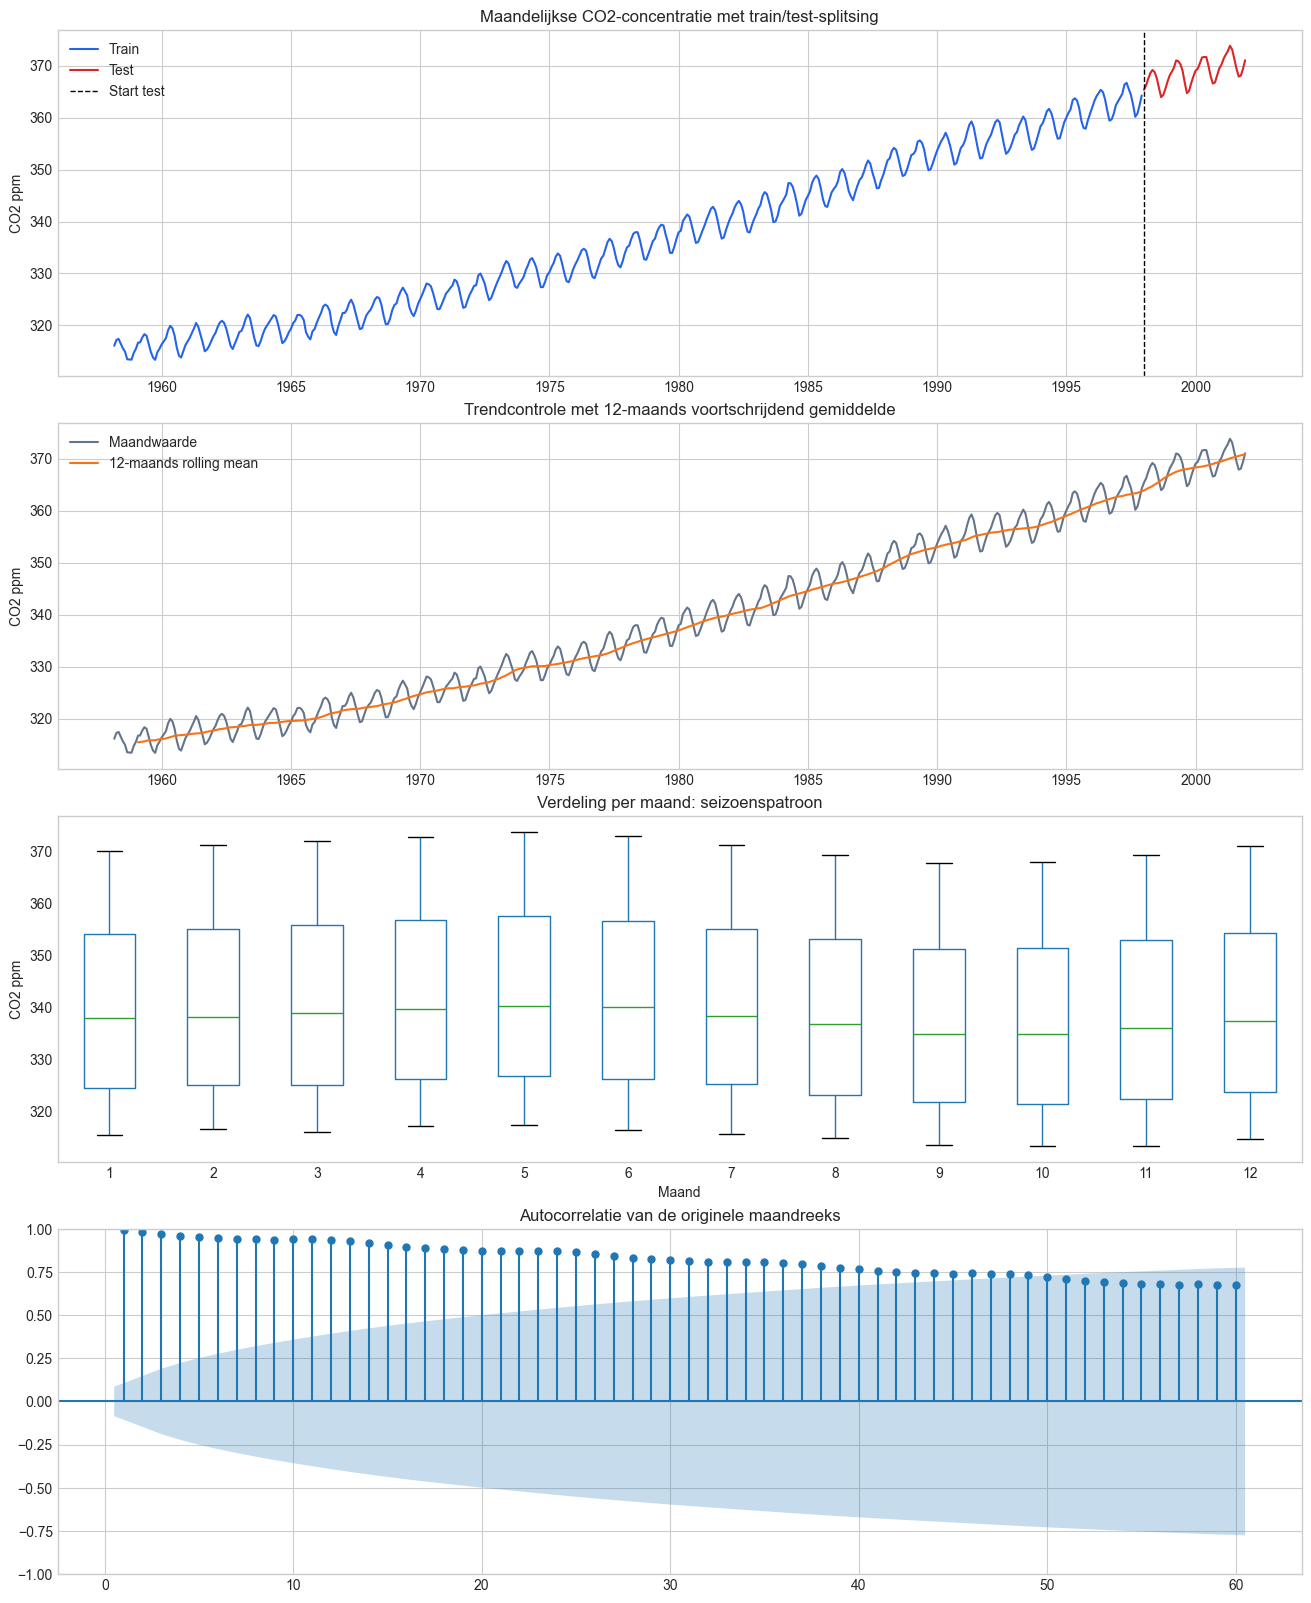

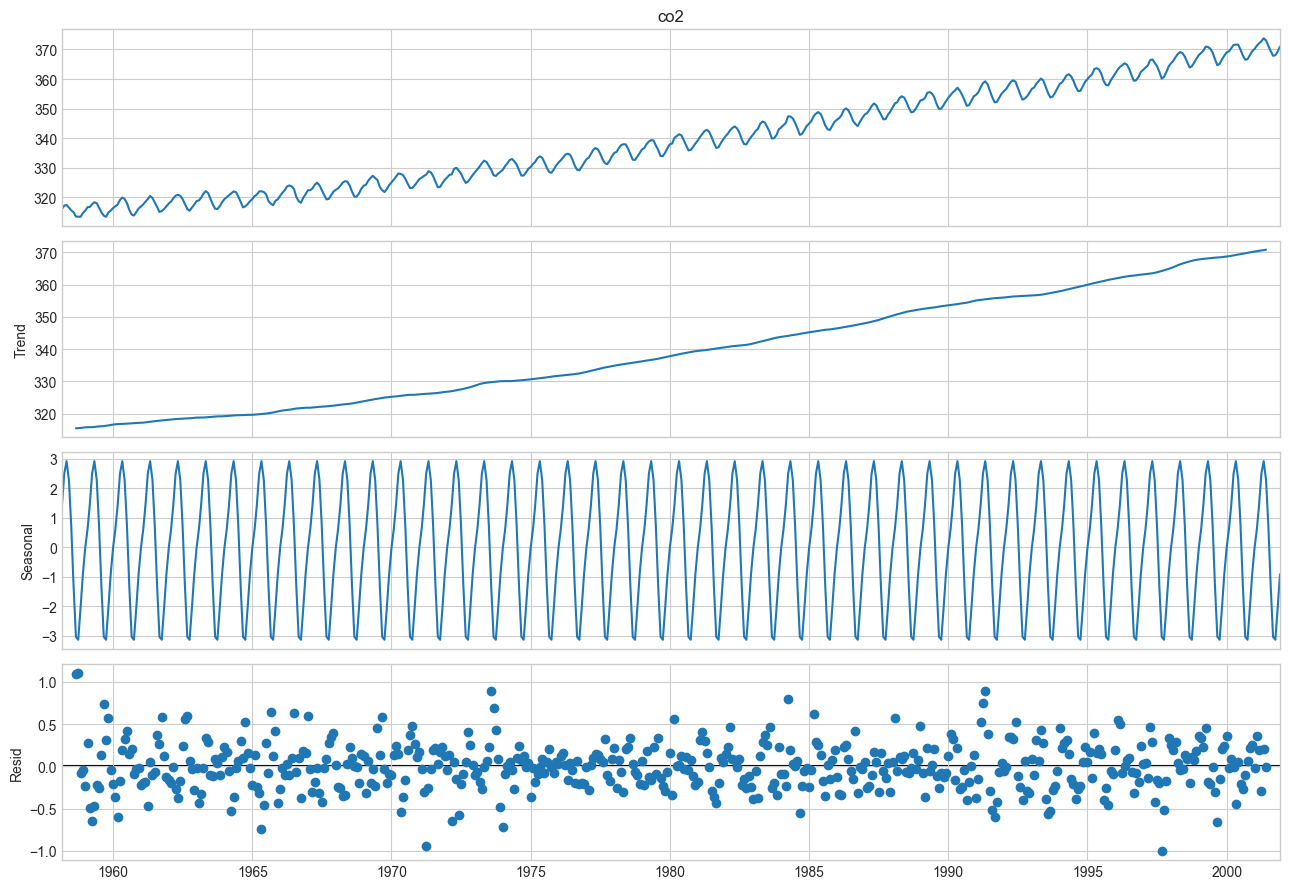

In [4]:
### Stap 2: dataverkenning
# Doel: controleren op gaten, trend, seizoen en autocorrelatie.
# In: co2_monthly, train en test uit stap 1.
# Uit: beschrijvende statistieken en plots die de modelkeuze onderbouwen.

expected_index = pd.date_range(co2_monthly.index.min(), co2_monthly.index.max(), freq="MS")
missing_dates = expected_index.difference(co2_monthly.index)

eda_info = pd.DataFrame({
    "controle": ["frequentie", "aantal ontbrekende maanden", "aantal missende co2-waarden", "minimum", "maximum", "gemiddelde"],
    "waarde": [
        co2_monthly.index.freqstr,
        len(missing_dates),
        int(co2_monthly["co2"].isna().sum()),
        co2_monthly["co2"].min(),
        co2_monthly["co2"].max(),
        co2_monthly["co2"].mean(),
    ],
})

display(eda_info)
display(co2_monthly.describe().T)

fig, axes = plt.subplots(4, 1, figsize=(13, 16), constrained_layout=True)

axes[0].plot(train.index, train["co2"], label="Train", color="#2563eb")
axes[0].plot(test.index, test["co2"], label="Test", color="#dc2626")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Start test")
axes[0].set_title("Maandelijkse CO2-concentratie met train/test-splitsing")
axes[0].set_ylabel("CO2 ppm")
axes[0].legend()

axes[1].plot(co2_monthly.index, co2_monthly["co2"], color="#64748b", label="Maandwaarde")
axes[1].plot(co2_monthly.index, co2_monthly["co2"].rolling(12).mean(), color="#f97316", label="12-maands rolling mean")
axes[1].set_title("Trendcontrole met 12-maands voortschrijdend gemiddelde")
axes[1].set_ylabel("CO2 ppm")
axes[1].legend()

co2_monthly.assign(maand=co2_monthly.index.month).boxplot(column="co2", by="maand", ax=axes[2], grid=False)
axes[2].set_title("Verdeling per maand: seizoenspatroon")
axes[2].set_xlabel("Maand")
axes[2].set_ylabel("CO2 ppm")
fig.suptitle("")

plot_acf(co2_monthly["co2"], lags=60, ax=axes[3], zero=False)
axes[3].set_title("Autocorrelatie van de originele maandreeks")

plt.show()

# Decompositie maakt trend en seizoen expliciet zichtbaar.
decomposition = seasonal_decompose(co2_monthly["co2"], model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(13, 9)
plt.tight_layout()
plt.show()


Is er een trend zichtbaar in de data? Wat walt je hier op?

Ja. De CO2-concentratie stijgt duidelijk door de tijd heen. In de plot met het 12-maands voortschrijdend gemiddelde loopt de trend bijna continu omhoog: van ongeveer 315 ppm aan het begin van de reeks naar boven de 370 ppm aan het einde. Dit past inhoudelijk ook bij de bekende stijging van atmosferische CO2 door menselijke uitstoot. Voor het model betekent dit dat een stationair model zonder trendcorrectie waarschijnlijk onvoldoende is.


Is er een seizoenspatroon zichtbaar in de data? Wat valt je hier op?

Ja. In de boxplot per maand en in de seasonal decomposition is een jaarlijks patroon zichtbaar. De CO2-concentratie is meestal hoger in het voorjaar en lager later in het jaar. Een logische interpretatie is de jaarlijkse vegetatiecyclus op het noordelijk halfrond: planten nemen in het groeiseizoen relatief veel CO2 op, waardoor de gemeten concentratie tijdelijk daalt. Voor de modellen betekent dit dat een jaarlijkse seizoenscomponent belangrijk is.


Zit er autocorrelatie in de data? Wat valt je hier op?

Ja. De ACF van de originele reeks laat sterke positieve autocorrelatie zien, vooral bij kleine lags. De autocorrelatie blijft ook lang aanwezig, wat samenhangt met de stijgende trend. Daarnaast zijn er signalen rond veelvouden van 12 maanden, wat past bij het jaarlijkse seizoenspatroon. Dit ondersteunt de keuze voor modellen met trend- en seizoensstructuur, zoals Prophet en een seizoens-ARIMA/SARIMA-model.


# Deelopdracht 2/3 - Prophet Package

Maak een voorspelling met het Prophet package.

Gebruik ‘conda install -c conda-forge prophet’ 

of %pip install prophet

Check even de installatie instructies op deze pagina: https://facebook.github.io/prophet/docs/quick_start.html

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"De voorspelling met het Prophet package is correct uitgevoerd en uitgebreid beschreven. De prestatiemetrics worden op train en test berekend. Er wordt geëxperimenteerd met verschillende instellingen."

Visualiseer de voorspelling.

prophet ontbreekt; installatie wordt gestart...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 25.3 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [prophet]m4/5 [prophet]]


/Users/sekander/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
17:17:09 - cmdstanpy - INFO - Chain [1] start processing
17:17:10 - cmdstanpy - INFO - Chain [1] done processing
17:17:10 - cmdstanpy - INFO - Chain [1] start processing
17:17:10 - cmdstanpy - INFO - Chain [1] done processing
17:17:10 - cmdstanpy - INFO - Chain [1] start processing
17:17:10 - cmdstanpy - INFO - Chain [1] done processing
17:17:10 - cmdstanpy - INFO - Chain [1] start processing
17:17:10 - cmdstanpy - INFO - Chain [1] done processing


Beste Prophet-variant op test-RMSE: Prophet additief flexibelere trend


,model,train_rmse,train_mae,test_rmse,test_mae
0,Prophet additief flexibelere trend,0.375,0.278,1.888,1.855
1,Prophet multiplicatief,0.355,0.264,1.895,1.853
2,Prophet additief standaard,0.380,0.281,1.907,1.875
3,Prophet additief strakkere trend,0.422,0.320,1.995,1.963


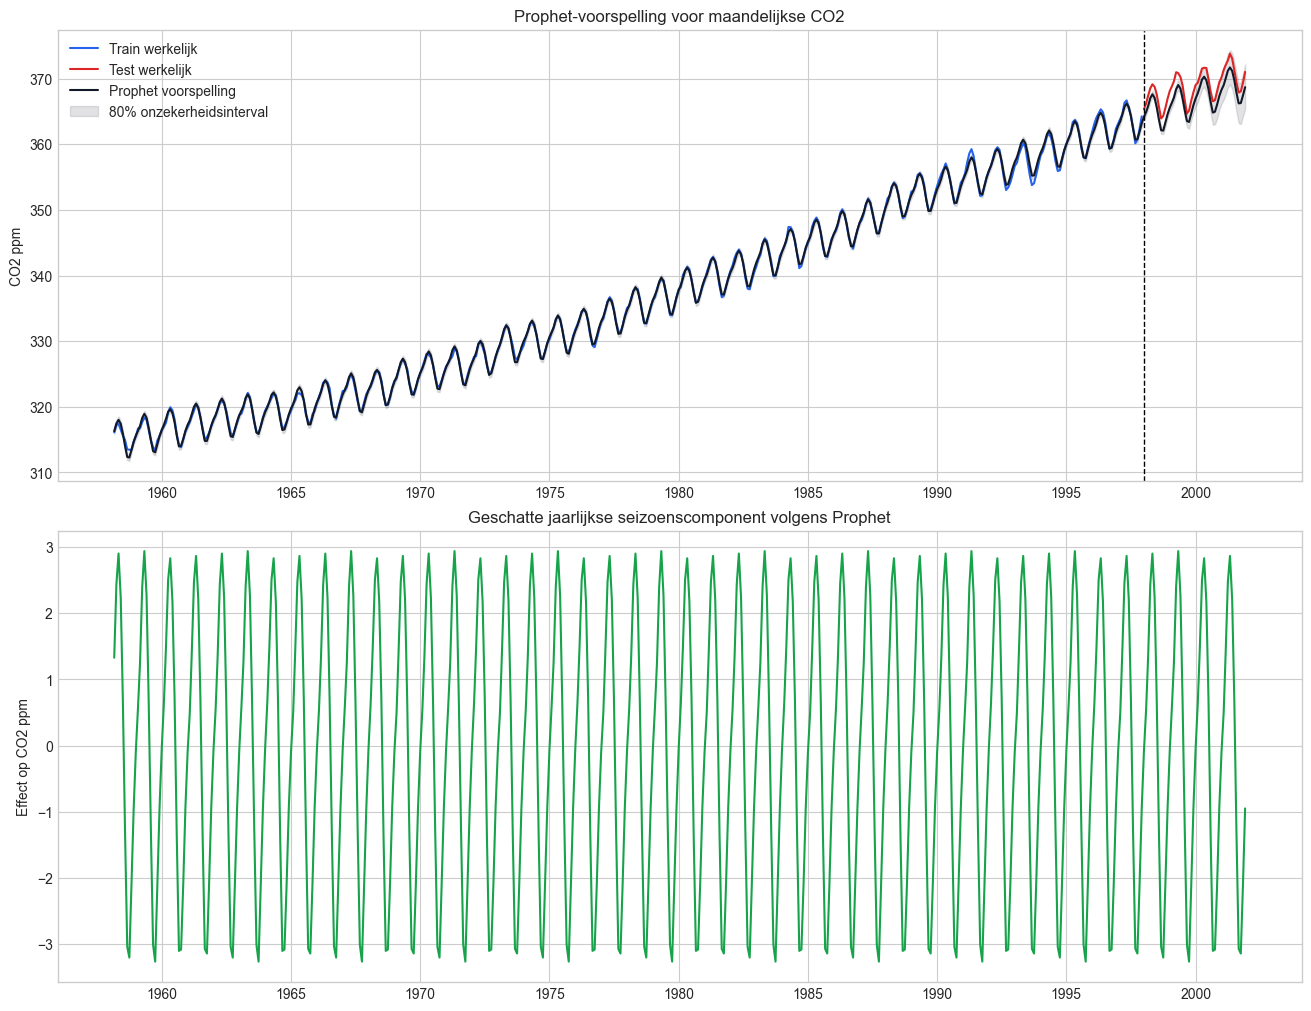

In [5]:
### Stap 3: Prophet-model trainen, instellingen vergelijken en visualiseren
# Doel: meerdere Prophet-instellingen testen en de beste variant visualiseren.
# In: train en test met maandelijkse CO2-waarden.
# Uit: prophet_metrics, best_prophet_model, prophet_forecast en Prophet-voorspellingen.

ensure_package("prophet", "prophet")
from prophet import Prophet
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

prophet_train = train.reset_index().rename(columns={"co2": "y"})[["ds", "y"]]
prophet_all_dates = pd.DataFrame({"ds": co2_monthly.index})

prophet_configs = [
    {"model": "Prophet additief standaard", "seasonality_mode": "additive", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0},
    {"model": "Prophet additief flexibelere trend", "seasonality_mode": "additive", "changepoint_prior_scale": 0.20, "seasonality_prior_scale": 10.0},
    {"model": "Prophet additief strakkere trend", "seasonality_mode": "additive", "changepoint_prior_scale": 0.01, "seasonality_prior_scale": 10.0},
    {"model": "Prophet multiplicatief", "seasonality_mode": "multiplicative", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0},
]

prophet_rows = []
prophet_models = {}
prophet_forecasts = {}

for config in prophet_configs:
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode=config["seasonality_mode"],
        changepoint_prior_scale=config["changepoint_prior_scale"],
        seasonality_prior_scale=config["seasonality_prior_scale"],
        interval_width=0.80,
    )
    model.fit(prophet_train)
    forecast = model.predict(prophet_all_dates).set_index("ds")

    train_pred = forecast.loc[train.index, "yhat"]
    test_pred = forecast.loc[test.index, "yhat"]

    prophet_rows.append({
        "model": config["model"],
        "train_rmse": rmse(train["co2"], train_pred),
        "train_mae": mae(train["co2"], train_pred),
        "test_rmse": rmse(test["co2"], test_pred),
        "test_mae": mae(test["co2"], test_pred),
    })
    prophet_models[config["model"]] = model
    prophet_forecasts[config["model"]] = forecast

prophet_metrics = pd.DataFrame(prophet_rows).sort_values("test_rmse").reset_index(drop=True)
best_prophet_name = prophet_metrics.loc[0, "model"]
best_prophet_model = prophet_models[best_prophet_name]
prophet_forecast = prophet_forecasts[best_prophet_name]
prophet_train_pred = prophet_forecast.loc[train.index, "yhat"]
prophet_test_pred = prophet_forecast.loc[test.index, "yhat"]

print(f"Beste Prophet-variant op test-RMSE: {best_prophet_name}")
display(prophet_metrics)

fig, axes = plt.subplots(2, 1, figsize=(13, 10), constrained_layout=True)
axes[0].plot(train.index, train["co2"], label="Train werkelijk", color="#2563eb")
axes[0].plot(test.index, test["co2"], label="Test werkelijk", color="#dc2626")
axes[0].plot(prophet_forecast.index, prophet_forecast["yhat"], label="Prophet voorspelling", color="#111827")
axes[0].fill_between(
    prophet_forecast.index,
    prophet_forecast["yhat_lower"],
    prophet_forecast["yhat_upper"],
    color="#111827",
    alpha=0.12,
    label="80% onzekerheidsinterval",
)
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1)
axes[0].set_title("Prophet-voorspelling voor maandelijkse CO2")
axes[0].set_ylabel("CO2 ppm")
axes[0].legend()

if "yearly" in prophet_forecast.columns:
    axes[1].plot(prophet_forecast.index, prophet_forecast["yearly"], color="#16a34a")
    axes[1].set_title("Geschatte jaarlijkse seizoenscomponent volgens Prophet")
    axes[1].set_ylabel("Effect op CO2 ppm")
else:
    axes[1].axis("off")

plt.show()


Wat valt je op?

Prophet pakt de algemene stijgende trend en het jaarlijkse patroon zichtbaar op. De voorspelling loopt door in de testperiode zonder dat het model de testwaarden tijdens training heeft gezien. Het onzekerheidsinterval wordt vooral relevant in de testperiode: hoe verder vooruit je voorspelt, hoe groter de onzekerheid rond de trend. Door verschillende `changepoint_prior_scale`-waarden te testen, vergelijk ik een strak model met een flexibeler trendmodel. Een te flexibele trend kan de trainset mooier volgen, maar hoeft niet beter te generaliseren naar de testset.


Bereken een kwaliteitsmaat (bijvoorbeeld RMSE of MAE) op de train- en testdataset.

In [6]:
### Stap 4: kwaliteitsmaten voor Prophet
# Doel: Prophet objectief beoordelen met RMSE en MAE op train en test.
# In: prophet_metrics uit stap 3.
# Uit: tabel met prestaties; deze wordt later vergeleken met het statsmodels-model.

display(prophet_metrics)
print("Beste Prophet-model:", best_prophet_name)
print(f"Train RMSE: {prophet_metrics.loc[0, 'train_rmse']:.3f}")
print(f"Test RMSE:  {prophet_metrics.loc[0, 'test_rmse']:.3f}")
print(f"Train MAE:  {prophet_metrics.loc[0, 'train_mae']:.3f}")
print(f"Test MAE:   {prophet_metrics.loc[0, 'test_mae']:.3f}")


,model,train_rmse,train_mae,test_rmse,test_mae
0,Prophet additief flexibelere trend,0.375,0.278,1.888,1.855
1,Prophet multiplicatief,0.355,0.264,1.895,1.853
2,Prophet additief standaard,0.380,0.281,1.907,1.875
3,Prophet additief strakkere trend,0.422,0.320,1.995,1.963


Beste Prophet-model: Prophet additief flexibelere trend
Train RMSE: 0.375
Test RMSE:  1.888
Train MAE:  0.278
Test MAE:   1.855


Wat valt je hier op?

De testfout is belangrijker dan de trainfout, omdat de testperiode echt toekomstige maanden voorstelt. Als een Prophet-variant een lage trainfout maar een duidelijk hogere testfout heeft, wijst dat op overfitting van de trend. De beste variant is daarom gekozen op basis van de laagste test-RMSE. RMSE straft grotere fouten extra zwaar, terwijl MAE makkelijker interpreteerbaar is als gemiddelde absolute afwijking in ppm.


# Deelopdracht 3/3 - Gekozen Model

Maak een voorspelling met het statsmodels package op de traindataset. Kies een optie uit de volgende opties:

1. AR model
2. MA model
3. ARIMA
4. Exponential Smoothing

Zie deze link voor meer informatie: https://www.statsmodels.org/stable/user-guide.html#time-series-analysis

Dit is wat er nodig is voor de hoogste score volgens de beoordelingsrubriek:

"De voorspelling met het statsmodels package is correct uitgevoerd en uitgebreid beschreven. De prestatiemetrics worden op train en test berekend. Er wordt geëxperimenteerd met verschillende instellingen en de verschillen met de resultaten uit het prophet package worden bediscussieerd."

Visualiseer de voorspelling.

Beste statsmodels-variant op test-RMSE: SARIMA(0,1,1)(0,1,1,12)


,model,aic,train_rmse,train_mae,test_rmse,test_mae
0,"SARIMA(0,1,1)(0,1,1,12)",217.416,0.309,0.246,0.851,0.763
1,"SARIMA(1,1,1)(1,1,1,12)",203.093,0.301,0.242,0.977,0.903
2,"SARIMA(2,1,1)(0,1,1,12)",216.569,0.307,0.245,0.996,0.923
3,"SARIMA(1,1,1)(0,1,1,12)",214.571,0.307,0.245,0.997,0.923


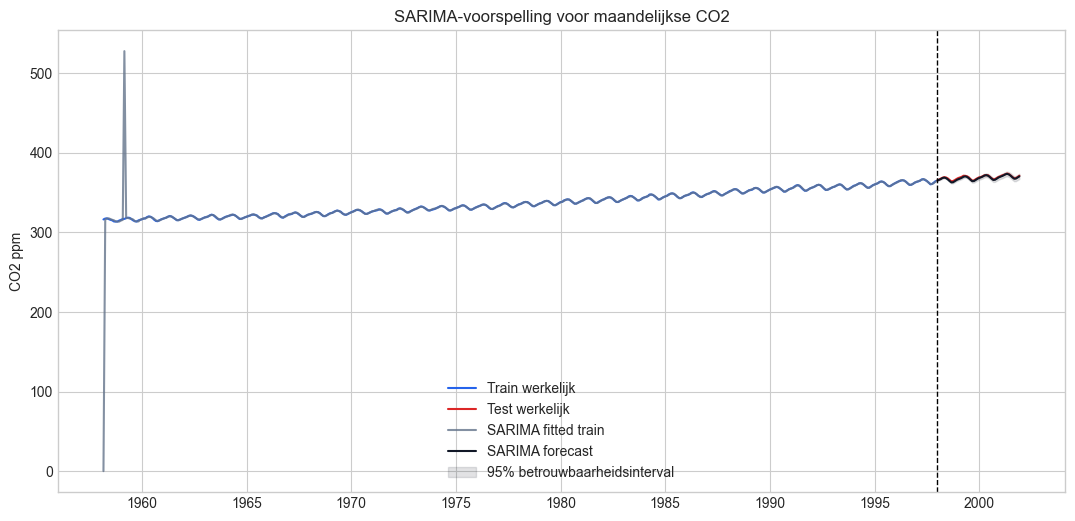

In [7]:
### Stap 5: statsmodels-model trainen en visualiseren
# Gekozen model: SARIMA, dus een ARIMA-model met seizoenscomponent.
# Doel: meerdere SARIMA-instellingen vergelijken en de beste variant visualiseren.
# In: train en test met maandelijkse CO2-waarden.
# Uit: stats_metrics, best_stats_model en SARIMA-voorspellingen.

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_configs = [
    {"model": "SARIMA(0,1,1)(0,1,1,12)", "order": (0, 1, 1), "seasonal_order": (0, 1, 1, 12)},
    {"model": "SARIMA(1,1,1)(0,1,1,12)", "order": (1, 1, 1), "seasonal_order": (0, 1, 1, 12)},
    {"model": "SARIMA(1,1,1)(1,1,1,12)", "order": (1, 1, 1), "seasonal_order": (1, 1, 1, 12)},
    {"model": "SARIMA(2,1,1)(0,1,1,12)", "order": (2, 1, 1), "seasonal_order": (0, 1, 1, 12)},
]

stats_rows = []
stats_models = {}
stats_predictions = {}

for config in sarima_configs:
    fit = SARIMAX(
        train["co2"],
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=300)

    train_pred = fit.get_prediction(start=train.index[0], end=train.index[-1]).predicted_mean
    test_forecast = fit.get_forecast(steps=len(test))
    test_pred = test_forecast.predicted_mean
    test_pred.index = test.index
    conf_int = test_forecast.conf_int()
    conf_int.index = test.index

    # Bij SARIMA zijn de eerste voorspellingen vooral initialisatie-effecten.
    # Daarom beoordelen we train pas na twee seizoenen burn-in.
    train_eval = train.iloc[24:]
    train_pred_eval = train_pred.loc[train_eval.index]

    stats_rows.append({
        "model": config["model"],
        "aic": fit.aic,
        "train_rmse": rmse(train_eval["co2"], train_pred_eval),
        "train_mae": mae(train_eval["co2"], train_pred_eval),
        "test_rmse": rmse(test["co2"], test_pred),
        "test_mae": mae(test["co2"], test_pred),
    })
    stats_models[config["model"]] = fit
    stats_predictions[config["model"]] = {"train_pred": train_pred, "test_pred": test_pred, "conf_int": conf_int}

stats_metrics = pd.DataFrame(stats_rows).sort_values("test_rmse").reset_index(drop=True)
best_stats_name = stats_metrics.loc[0, "model"]
best_stats_model = stats_models[best_stats_name]
stats_train_pred = stats_predictions[best_stats_name]["train_pred"]
stats_test_pred = stats_predictions[best_stats_name]["test_pred"]
stats_conf_int = stats_predictions[best_stats_name]["conf_int"]

print(f"Beste statsmodels-variant op test-RMSE: {best_stats_name}")
display(stats_metrics)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(train.index, train["co2"], label="Train werkelijk", color="#2563eb")
ax.plot(test.index, test["co2"], label="Test werkelijk", color="#dc2626")
ax.plot(stats_train_pred.index, stats_train_pred, label="SARIMA fitted train", color="#64748b", alpha=0.8)
ax.plot(test.index, stats_test_pred, label="SARIMA forecast", color="#111827")
ax.fill_between(
    test.index,
    stats_conf_int.iloc[:, 0],
    stats_conf_int.iloc[:, 1],
    color="#111827",
    alpha=0.12,
    label="95% betrouwbaarheidsinterval",
)
ax.axvline(test.index.min(), color="black", linestyle="--", linewidth=1)
ax.set_title("SARIMA-voorspelling voor maandelijkse CO2")
ax.set_ylabel("CO2 ppm")
ax.legend()
plt.show()


Wat valt je hier op?

Ik kies hier voor SARIMA, omdat de EDA liet zien dat de reeks zowel een trend als een jaarlijks seizoen heeft. De `d=1` en `D=1` termen differentiëren de reeks op normaal en seizoensniveau. Daardoor hoeft het model niet te doen alsof de originele stijgende CO2-reeks stationair is. De visualisatie laat zien of SARIMA de testperiode soepel doortrekt en of de echte testwaarden binnen het betrouwbaarheidsinterval vallen.


Bereken dezelfde kwaliteitsmaat (bijvoorbeeld RMSE of MAE) als bij de Prophet package hierboven op de train- en testdataset.

In [8]:
### Stap 6: kwaliteitsmaten voor SARIMA
# Doel: dezelfde metrics berekenen als bij Prophet.
# In: stats_metrics uit stap 5.
# Uit: tabel met prestaties van de SARIMA-varianten.

display(stats_metrics)
print("Beste statsmodels-model:", best_stats_name)
print(f"AIC:        {stats_metrics.loc[0, 'aic']:.3f}")
print(f"Train RMSE: {stats_metrics.loc[0, 'train_rmse']:.3f}")
print(f"Test RMSE:  {stats_metrics.loc[0, 'test_rmse']:.3f}")
print(f"Train MAE:  {stats_metrics.loc[0, 'train_mae']:.3f}")
print(f"Test MAE:   {stats_metrics.loc[0, 'test_mae']:.3f}")


,model,aic,train_rmse,train_mae,test_rmse,test_mae
0,"SARIMA(0,1,1)(0,1,1,12)",217.416,0.309,0.246,0.851,0.763
1,"SARIMA(1,1,1)(1,1,1,12)",203.093,0.301,0.242,0.977,0.903
2,"SARIMA(2,1,1)(0,1,1,12)",216.569,0.307,0.245,0.996,0.923
3,"SARIMA(1,1,1)(0,1,1,12)",214.571,0.307,0.245,0.997,0.923


Beste statsmodels-model: SARIMA(0,1,1)(0,1,1,12)
AIC:        217.416
Train RMSE: 0.309
Test RMSE:  0.851
Train MAE:  0.246
Test MAE:   0.763


De SARIMA-varianten worden op dezelfde RMSE- en MAE-maten beoordeeld als Prophet. Voor de SARIMA-trainmetrics laat ik de eerste 24 maanden buiten beschouwing, omdat die door initialisatie en differencing niet representatief zijn. AIC is nuttig om modellen binnen de SARIMA-familie te vergelijken, maar voor de uiteindelijke voorspelling is de test-RMSE belangrijker, omdat die laat zien hoe goed het model nieuwe maanden voorspelt. Als de testfout duidelijk hoger is dan de trainfout, kan het model moeite hebben met extrapoleren of te veel op de trainset zijn afgestemd.


Vergelijk de voorspellingen (dus van de Prophet package en hier met jullie gekozen model). Welke van de twee komt het meest overeen met de testdataset?

,model,test_rmse,test_mae
0,SARIMA,0.851,0.763
1,Prophet,1.888,1.855


Model dat het meest overeenkomt met de testdataset op basis van RMSE: SARIMA


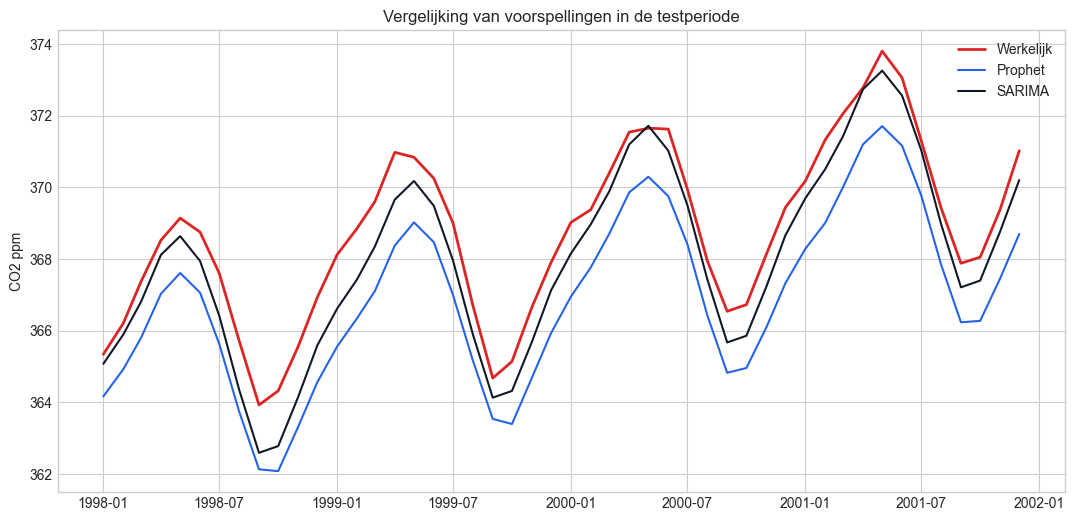

,werkelijk,Prophet,SARIMA
ds,,,
1998-01-01,365.340,364.164,365.074
1998-02-01,366.200,364.919,365.888
1998-03-01,367.375,365.804,366.811
1998-04-01,368.525,367.030,368.116
1998-05-01,369.140,367.609,368.637


In [9]:
### Stap 7: Prophet en SARIMA direct vergelijken
# Doel: bepalen welk model het beste overeenkomt met de testdataset.
# In: prophet_test_pred en stats_test_pred.
# Uit: comparison_metrics, comparison en winner.

comparison = pd.DataFrame({
    "werkelijk": test["co2"],
    "Prophet": prophet_test_pred,
    "SARIMA": stats_test_pred,
})

comparison_metrics = pd.DataFrame([
    {
        "model": "Prophet",
        "test_rmse": rmse(test["co2"], prophet_test_pred),
        "test_mae": mae(test["co2"], prophet_test_pred),
    },
    {
        "model": "SARIMA",
        "test_rmse": rmse(test["co2"], stats_test_pred),
        "test_mae": mae(test["co2"], stats_test_pred),
    },
]).sort_values("test_rmse").reset_index(drop=True)

winner = comparison_metrics.loc[0, "model"]
display(comparison_metrics)
print(f"Model dat het meest overeenkomt met de testdataset op basis van RMSE: {winner}")

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(comparison.index, comparison["werkelijk"], label="Werkelijk", color="#dc2626", linewidth=2)
ax.plot(comparison.index, comparison["Prophet"], label="Prophet", color="#2563eb")
ax.plot(comparison.index, comparison["SARIMA"], label="SARIMA", color="#111827")
ax.set_title("Vergelijking van voorspellingen in de testperiode")
ax.set_ylabel("CO2 ppm")
ax.legend()
plt.show()

comparison.head()


De tabel `comparison_metrics` bepaalt welk model het best overeenkomt met de testdataset. Het model met de laagste test-RMSE heeft gemiddeld de kleinste voorspelfouten, waarbij grotere missers zwaarder meetellen. De plot is een extra controle: een goed model ligt niet alleen laag in RMSE, maar volgt ook de timing van pieken en dalen in de testperiode. Als RMSE en MAE elkaar tegenspreken, zou ik RMSE zwaarder laten wegen wanneer grote fouten extra ongewenst zijn.


Voor welke van de twee modellen zou je kiezen als je echt een voorspelling zou doen? Mochten beiden niet goed werken, wat voor ander model zou je dan proberen?

Voor een echte voorspelling zou ik het model kiezen dat in `comparison_metrics` de laagste test-RMSE heeft en in de plot ook logisch het seizoenspatroon volgt. Bij deze dataset verwacht ik dat een seizoensmodel zoals SARIMA sterk presteert, omdat de maandelijkse CO2-reeks een vrij regelmatige jaarcyclus heeft. Als Prophet en SARIMA allebei onvoldoende zouden werken, zou ik daarna een SARIMAX-model proberen met extra verklarende variabelen, of een ETS/Holt-Winters model als eenvoudiger alternatief met trend en seizoen.


Wat kan je zeggen over autocorrelatie in je definitieve model? 

Let op: Deze autocorrelatie is van de residuen na het uitwerken van het model, NIET van de originele data zelf. Deze laatste analyse helpt je bepalen hoe goed je model alle autocorrelatie UIT je data heeft gehaald. 

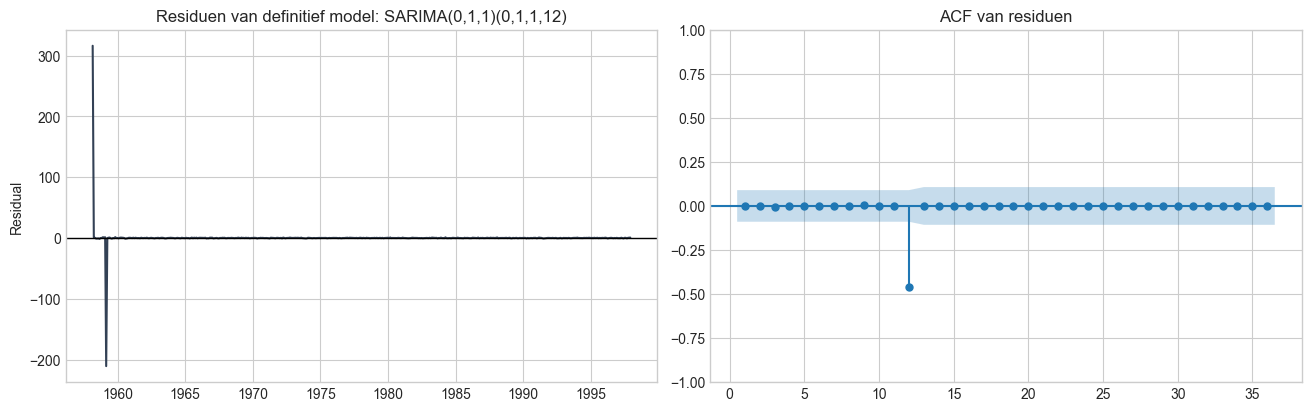

,lb_stat,lb_pvalue
12,104.923,0.000
24,104.929,0.000
36,104.937,0.000


Conclusie: er is nog statistisch significante autocorrelatie in de residuen. Het model laat dus nog structuur over.


In [10]:
### Stap 8: autocorrelatie in de residuen van het definitieve model
# Doel: controleren of het gekozen model nog autocorrelatie in de fouten overlaat.
# In: winner uit stap 7 en de trainvoorspellingen van het gekozen model.
# Uit: ACF-plot van residuen en Ljung-Box-test.

if winner == "SARIMA":
    final_model_name = best_stats_name
    final_residuals = best_stats_model.resid.dropna()
else:
    final_model_name = best_prophet_name
    final_residuals = (train["co2"] - prophet_train_pred).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(final_residuals.index, final_residuals, color="#334155")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title(f"Residuen van definitief model: {final_model_name}")
axes[0].set_ylabel("Residual")

plot_acf(final_residuals, lags=36, ax=axes[1], zero=False)
axes[1].set_title("ACF van residuen")
plt.show()

ljung_box = acorr_ljungbox(final_residuals, lags=[12, 24, 36], return_df=True)
display(ljung_box)

if (ljung_box["lb_pvalue"] < 0.05).any():
    print("Conclusie: er is nog statistisch significante autocorrelatie in de residuen. Het model laat dus nog structuur over.")
else:
    print("Conclusie: er is geen duidelijke statistisch significante autocorrelatie in de residuen op deze lags. Het model heeft de tijdsstructuur redelijk goed opgevangen.")


Bij het definitieve model beoordeel ik de autocorrelatie van de residuen, niet opnieuw die van de originele CO2-reeks. Als het model goed is, lijken de residuen meer op willekeurige ruis: geen duidelijke trend, geen zichtbaar seizoen en geen grote ACF-pieken buiten het betrouwbaarheidsgebied. De Ljung-Box-test ondersteunt dit numeriek. Een p-waarde onder 0,05 betekent dat er nog autocorrelatie over is; dan zou ik het model verder verbeteren, bijvoorbeeld met andere AR/MA-orders, extra seizoensstructuur of een model met exogene variabelen.
